# Lab 1 Task 1

## 1. Implement the following layers as Python functions (both forward and backward propagation)
* Inner-product layer
* Activation layer(Sigmoid or Rectified)
* Softmax layer

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
%cd /content/drive/MyDrive/AI_Lab1

In [26]:
import os
from typing import Callable, Iterable
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm

In [43]:
EPOCH = 100
BATCH_SIZE = 16
LEARNING_RATE = 0.05

In [28]:
class Parameter:
    def __init__(self, data: np.ndarray) -> None:
        self.data = data
        self.grad = None


class Module:
    def __call__(self, *args, **kwargs) -> np.ndarray:
        return self.forward(*args, **kwargs)

    def __repr__(self) -> str:
        layers = '\n'.join([f'  ({k}): {v}' for k, v in self.__dict__.items()])
        return f'{self.__class__.__name__}(\n{layers}\n)'

In [56]:
class Linear(Module):
    def __init__(self, in_features, out_features) -> None:
        super().__init__()
        self.in_features = in_features
        self.out_features = out_features

        # Initialize weights and biases
        init_factor = 0.01
        self.W = Parameter(np.random.randn(in_features, out_features) * init_factor)
        self.b = Parameter(np.zeros((1, out_features)))

        # Cache for backward pass
        self.x = None

    def forward(self, x):
        # 學生實作部分：reutrn output of linear layer
        self.x = x
        return x @ self.W.data + self.b.data

    def backward(self, dy):
        # 學生實作部分：return gradient w.r.t. input and compute gradients for weights and biases
        dx = dy @ self.W.data.T
        self.W.grad = self.x.T @ dy
        self.b.grad = np.sum(dy, axis=0, keepdims=True)
        return dx
        

    def parameters(self):
        return self.W, self.b

    def __repr__(self) -> str:
        return f'{self.__class__.__name__}(in_features={self.in_features}, out_features={self.out_features})'


class ReLU(Module):
    def __init__(self) -> None:
        super().__init__()
        self.x = None

    def forward(self, x):
        # 學生實作部分：return output of ReLU activation
        self.x = x
        return np.maximum(0, x)

    def backward(self, dy):
        # 學生實作部分：return gradient w.r.t. input
        dx = dy * (self.x > 0)
        return dx


    def __repr__(self) -> str:
        return f'{self.__class__.__name__}()'


class Sigmoid(Module):
    def __init__(self) -> None:
        super().__init__()
        self.y = None

    def forward(self, x):
        # 學生實作部分：return output of Sigmoid activation
        self.y = 1 / (1 + np.exp(-x))
        return self.y

    def backward(self, dy):
        # 學生實作部分：return gradient w.r.t. input
        dx = dy * self.y * (1 - self.y)
        return dx


    def __repr__(self) -> str:
        return f'{self.__class__.__name__}()'


class Softmax(Module):
    def __init__(self) -> None:
        super().__init__()
        self.y = None

    def forward(self, x):
        # 學生實作部分：return output of Softmax activation
        exps = np.exp(x - np.max(x, axis=1, keepdims=True))
        self.y = exps / np.sum(exps, axis=1, keepdims=True)
        return self.y

    def backward(self, dy):
        # 這邊我們設定同學們會將Softmax和Cross-Entropy Loss一起使用
        # 因此backward pass根據講義上的說明使用簡化的版本在Cross-Entropy Loss的部分完成
        # 若同學的softmax沒有和Cross-Entropy Loss一起使用，請自行實作完整的backward pass
        return dy

    # def backward(self, dy):
    #     dx = np.empty_like(dy)
    #     for i, (yi, dyi) in enumerate(zip(self.y, dy)):
    #         J = np.diag(yi) - np.outer(yi, yi)
    #         dx[i] = dyi @ J
    #     return dx

    def __repr__(self) -> str:
        return f'{self.__class__.__name__}()'


class Dropout(Module):
    def __init__(self, p=0.5) -> None:
        super().__init__()
        self.p = p
        self.mask = None
        self.training = True  # 用來區分 train / eval 模式

    def forward(self, x):
        if self.training:
            self.mask = (np.random.rand(*x.shape) > self.p).astype(np.float32)
            return x * self.mask / (1 - self.p)
        else:
            return x

    def backward(self, dy):
        if self.training:
            return dy * self.mask / (1 - self.p)
        else:
            return dy

    def train(self):
        self.training = True

    def eval(self):
        self.training = False

    def __repr__(self) -> str:
        return f"{self.__class__.__name__}(p={self.p})"

In [40]:
class MLP(Module):
    def __init__(self) -> None:
        # 學生實作部分：design your Model architecture here
        self.fc1 = Linear(784, 128)
        self.relu1 = ReLU()
        self.fc2 = Linear(128, 10)
        self.relu2 = ReLU()
        self.fc3 = Linear(10, 10)
        self.softmax = Softmax()

    def forward(self, x):
        # 學生實作部分：compute forward pass through your model
        x = self.fc1(x)
        x = self.relu1(x)
        x = self.fc2(x)
        x = self.relu2(x)
        x = self.fc3(x)
        x = self.softmax(x)
        return x

    def backward(self, dy):
        # Backpropagate through the layers in reverse order
        dy = self.softmax.backward(dy)
        dy = self.fc3.backward(dy)
        dy = self.relu2.backward(dy)
        dy = self.fc2.backward(dy)
        dy = self.relu1.backward(dy)
        dy = self.fc1.backward(dy)
        return dy

    def parameters(self):
        return self.fc1.parameters() + self.fc2.parameters()

In [64]:
class MLP_WithDropOut(Module):
    def __init__(self) -> None:
        self.fc1 = Linear(784, 128)
        self.relu1 = ReLU()
        self.drop1 = Dropout(p=0.2)
        self.fc2 = Linear(128, 64)
        self.relu2 = ReLU()
        self.drop2 = Dropout(p=0.2)
        self.fc3 = Linear(64, 10)
        self.softmax = Softmax()

    def forward(self, x):
        x = self.fc1(x)
        x = self.relu1(x)
        x = self.drop1(x)
        x = self.fc2(x)
        x = self.relu2(x)
        x = self.drop2(x)
        x = self.fc3(x)
        x = self.softmax(x)
        return x

    def backward(self, dy):
        dy = self.softmax.backward(dy)
        dy = self.fc3.backward(dy)
        dy = self.drop2.backward(dy)
        dy = self.relu2.backward(dy)
        dy = self.fc2.backward(dy)
        dy = self.drop1.backward(dy)
        dy = self.relu1.backward(dy)
        dy = self.fc1.backward(dy)
        return dy
    
    def train(self):
        self.drop1.train()
        self.drop2.train()

    def eval(self):
        self.drop1.eval()
        self.drop2.eval()

    def parameters(self):
        return self.fc1.parameters() + self.fc2.parameters() + self.fc3.parameters()

## 2. Implement training and testing process
* included cross-validation

In [38]:
class MNIST:
    # root請根據你的檔案位置更改
    def __init__(self, root='./', train=True, transform: Callable = None) -> None:
        path = os.path.join(root, 'mnist_train.csv' if train else 'mnist_test.csv')
        self.data = np.loadtxt(path, delimiter=',')
        self.transform = transform
        self.image_size = 28
        self.num_classes = 10
        self.classes = np.arange(self.num_classes)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        label = (self.data[idx, 0] == self.classes).astype(
            np.float32
        )  # one-hot encoding
        image = (
            self.data[idx, 1:]
            .reshape(self.image_size * self.image_size)
            .astype(np.float32)
        )
        if self.transform:
            image = self.transform(image)
        return image, label


class Subset:
    def __init__(self, dataset, indices: Iterable) -> None:
        self.dataset = dataset
        self.indices = indices

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        return self.dataset[self.indices[idx]]


class DataLoader:
    def __init__(self, dataset, batch_size=1) -> None:
        self.dataset = dataset
        self.batch_size = batch_size
        self.indices = np.arange(len(dataset))

    def __len__(self):
        return (len(self.dataset) + self.batch_size - 1) // self.batch_size

    def __iter__(self):
        for start_idx in range(0, len(self.dataset), self.batch_size):
            end_idx = min(start_idx + self.batch_size, len(self.dataset))
            batch_indices = self.indices[start_idx:end_idx]

            batch_images = []
            batch_labels = []

            for idx in batch_indices:
                image, label = self.dataset[idx]
                batch_images.append(image)
                batch_labels.append(label)

            yield np.array(batch_images), np.array(batch_labels)

In [33]:
# Separate train_imgs, train_labels into training and validation
# root請根據你的檔案位置更改
def load_mnist_data(
    root="./", batch_size=1, split_ratio=0.1, transform=None
) -> tuple[DataLoader, DataLoader, DataLoader]:
    def _split_dataset(dataset, split_ratio):
        # 學生實作部分：split dataset into training and validation sets
        # hint: return Subset(dataset, train_indices), Subset(dataset, valid_indices)
        num_samples = len(dataset)
        indices = np.arange(num_samples)
        np.random.shuffle(indices)
        split_point = int(num_samples * (1 - split_ratio))
        train_indices = indices[:split_point]
        valid_indices = indices[split_point:]        
        
        return Subset(dataset, train_indices), Subset(dataset, valid_indices)
        

    trainset = MNIST(root=root, train=True, transform=transform)
    testset = MNIST(root=root, train=False, transform=transform)
    trainset, validset = _split_dataset(trainset, split_ratio=split_ratio)
    trainldr = DataLoader(trainset, batch_size=batch_size)
    validldr = DataLoader(validset, batch_size=batch_size)
    testldr = DataLoader(testset, batch_size=batch_size)
    return trainldr, validldr, testldr

In [34]:
class CrossEntropyLoss(Module):
    def __init__(self, epsilon=1e-15) -> None:
        super().__init__()
        self.epsilon = epsilon  # small value to avoid log(0)
        self.y_pred = None
        self.y_true = None

    def forward(self, y_pred, y_true):
        self.y_pred = np.clip(y_pred, self.epsilon, 1 - self.epsilon)
        self.y_true = y_true
        batch_size = y_true.shape[0]
        loss = -np.sum(y_true * np.log(self.y_pred)) / batch_size
        return loss

    def backward(self):
        batch_size = self.y_true.shape[0]
        grad = (self.y_pred - self.y_true) / batch_size
        return grad

    def __repr__(self) -> str:
        return f"{self.__class__.__name__}()"


class SGD:
    def __init__(self, params: Iterable, lr: float = 1e-3) -> None:
        self.params = params
        self.lr = lr

    def step(self):
        for param in self.params:
            if param.grad is not None:
                param.data -= self.lr * param.grad

    def zero_grad(self):
        for param in self.params:
            if param.grad is not None:
                param.grad.fill(0)

In [46]:
def train_one_epoch(model: Module, trainldr: Iterable, criterion, optimizer) -> tuple[float, float]:
    total = 0
    correct = 0
    total_loss = 0
    for x, y in tqdm(trainldr, leave=False, desc='Training',colour='green'):
        # 學生實作部分：complete the training process through one epoch
        # Hint:
        # 1. forward propagation
        # 2. compute loss
        # 3. compute accuracy
        # 4. backward propagation
        # 5. update parameters
        # 1. forward
        out = model.forward(x)

        # 2. loss
        loss = criterion.forward(out, y)
        total_loss += loss * len(y)

        # 3. accuracy
        preds = np.argmax(out, axis=1)
        labels = np.argmax(y, axis=1)   # one-hot → scalar
        correct += np.sum(preds == labels)
        total += len(y)

        # 4. backward
        dy = criterion.backward()  # gradient from CE loss
        model.backward(dy)

        # 5. update
        optimizer.step()
    avg_loss = total_loss / total
    accuracy = correct / total
    return avg_loss, accuracy


def evaluate(model: Module, testldr: Iterable) -> tuple[float, float]:
    total = 0
    correct = 0
    total_loss = 0
    criterion = CrossEntropyLoss()  # separate criterion from training
    for x, y in tqdm(testldr):
        # 學生實作部分：complete the evaluation process
        # Hint:
        # 1. forward propagation
        # 2. compute total loss
        # 3. compute correct and total
        # 1. forward
        out = model.forward(x)
        # 2. loss
        loss = criterion.forward(out, y)
        total_loss += loss * len(y)
        # 3. accuracy
        preds = np.argmax(out, axis=1)
        labels = np.argmax(y, axis=1)
        correct += np.sum(preds == labels)
        total += len(y)

    avg_loss = total_loss / total
    accuracy = correct / total
    return avg_loss, accuracy


def train(model: MLP, trainldr: Iterable, validldr: Iterable, epochs=10, lr=1e-3):
    criterion = CrossEntropyLoss()
    # 這邊提供SGD作為optimizer，同學也可以根據自己人需求更換其他optimizer
    optimizer = SGD(model.parameters(), lr=lr)
    train_loss = []
    train_acc = []
    valid_loss = []
    valid_acc = []

    for epoch in range(epochs):
        current_lr = adjust_lr(optimizer, epoch, init_lr=lr, step_size=10, gamma=0.5)
        print(f"[Epoch {epoch}] LR = {current_lr:.5f}")
        loss, acc = train_one_epoch(model, trainldr, criterion, optimizer)
        train_loss.append(loss)
        train_acc.append(acc)
        print(f'epoch {epoch:d}: train_loss = {loss}, train_acc = {acc}')

        loss, acc = evaluate(model, validldr)
        valid_loss.append(loss)
        valid_acc.append(acc)
        print(f'epoch {epoch:d}: valid_loss = {loss}, valid_acc = {acc}\n')

    return train_loss, train_acc, valid_loss, valid_acc


def adjust_lr(optimizer, epoch, init_lr=0.1, step_size=10, gamma=0.5):
    lr = init_lr * (gamma ** (epoch // step_size))
    optimizer.lr = lr  # ✅ 直接改 optimizer 的 lr
    return lr  # 只是回傳方便印出

In [47]:
def transform(x):
    """map pixels information from range(0, 255) to range(0.01, 1)"""
    return np.asarray(x) * 0.99 + 0.01

# "../data"請根據你的檔案位置更改
trainldr, validldr, testldr = load_mnist_data(
    "./", batch_size=BATCH_SIZE, transform=transform
)
print(f"train set: {len(trainldr)} images")
print(f"validation set: {len(validldr)} images")
print(f"test set: {len(testldr)} images")
for x, y in trainldr:
    print(f"x shape: {x.shape}")
    print(f"y shape: {y.shape}")
    print("y:", y)
    break

net = MLP()
print(net)
# 你可以調整 epochs 和 lr 來觀察不同的訓練效果
train_loss, train_acc, valid_loss, valid_acc = train(
    net, trainldr, validldr, epochs=EPOCH, lr=LEARNING_RATE
)

train set: 3375 images
validation set: 375 images
test set: 625 images
x shape: (16, 784)
y shape: (16, 10)
y: [[0. 0. 0. 0. 0. 0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 1. 0. 0.]
 [0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]]
MLP(
  (fc1): Linear(in_features=784, out_features=128)
  (relu1): ReLU()
  (fc2): Linear(in_features=128, out_features=10)
  (relu2): ReLU()
  (fc3): Linear(in_features=10, out_features=10)
  (softmax): Softmax()
)
[Epoch 0] LR = 0.05000


epoch 0: train_loss = 0.3332593670639739, train_acc = 0.9047407407407407


100%|██████████| 375/375 [00:00<00:00, 1035.06it/s]


epoch 0: valid_loss = 0.2624764573401304, valid_acc = 0.9323333333333333

[Epoch 1] LR = 0.05000


epoch 1: train_loss = 0.15032843449332559, train_acc = 0.9586296296296296


...

100%|██████████| 375/375 [00:00<00:00, 1013.44it/s]


epoch 98: valid_loss = 0.1839235318000411, valid_acc = 0.9745

[Epoch 99] LR = 0.00010


epoch 99: train_loss = 0.0007547895325522016, train_acc = 1.0


100%|██████████| 375/375 [00:00<00:00, 1007.61it/s]

epoch 99: valid_loss = 0.1839273866260106, valid_acc = 0.9745



In [ ]:
# Using test_images and test_labels to do the final test
test_loss, test_acc = evaluate(net, testldr)
print(f"test_loss = {test_loss}, test_acc = {test_acc}")

In [65]:
def train_with_dropout(
    model: MLP_WithDropOut, trainldr: Iterable, validldr: Iterable, epochs=10, lr=1e-3
):
    criterion = CrossEntropyLoss()
    optimizer = SGD(model.parameters(), lr=lr)
    train_loss, train_acc, valid_loss, valid_acc = [], [], [], []
    lr_history = []

    for epoch in range(epochs):
        current_lr = adjust_lr(optimizer, epoch, init_lr=lr, step_size=10, gamma=0.5)
        lr_history.append(current_lr)
        print(f"[Epoch {epoch}] LR = {current_lr:.5f}")

        model.train()  # 啟用 dropout
        loss, acc = train_one_epoch(model, trainldr, criterion, optimizer)
        train_loss.append(loss)
        train_acc.append(acc)

        model.eval()  # 關閉 dropout
        loss, acc = evaluate(model, validldr)
        valid_loss.append(loss)
        valid_acc.append(acc)

        print(
            f"epoch {epoch:d}: train_loss = {train_loss[-1]}, train_acc = {train_acc[-1]}"
        )
        print(
            f"epoch {epoch:d}: valid_loss = {valid_loss[-1]}, valid_acc = {valid_acc[-1]}\n"
        )

    return train_loss, train_acc, valid_loss, valid_acc, lr_history


def transform(x):
    return np.asarray(x) / 255.0


# "../data"請根據你的檔案位置更改
trainldr, validldr, testldr = load_mnist_data(
    "./", batch_size=BATCH_SIZE, transform=transform
)
print(f"train set: {len(trainldr)} images")
print(f"validation set: {len(validldr)} images")
print(f"test set: {len(testldr)} images")
for x, y in trainldr:
    print(f"x shape: {x.shape}")
    print(f"y shape: {y.shape}")
    print("y:", y)
    break
net = MLP_WithDropOut()
print(net)
train_loss, train_acc, valid_loss, valid_acc, lr_history = train_with_dropout(
    net, trainldr, validldr, epochs=EPOCH, lr=LEARNING_RATE
)

train set: 3375 images
validation set: 375 images
test set: 625 images
x shape: (16, 784)
y shape: (16, 10)
y: [[1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 1. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]]
MLP_WithDropOut(
  (fc1): Linear(in_features=784, out_features=128)
  (relu1): ReLU()
  (drop1): Dropout(p=0.2)
  (fc2): Linear(in_features=128, out_features=64)
  (relu2): ReLU()
  (drop2): Dropout(p=0.2)
  (fc3): Linear(in_features=64, out_features=10)
  (softmax): Softmax()
)
[Epoch 0] LR = 0.05000


100%|██████████| 375/375 [00:00<00:00, 1080.48it/s]           2.44it/s]


epoch 0: train_loss = 0.9295655523813666, train_acc = 0.6804814814814815
epoch 0: valid_loss = 0.24635886953723, valid_acc = 0.9263333333333333

[Epoch 1] LR = 0.05000


100%|██████████| 375/375 [00:00<00:00, 1020.02it/s]           6.44it/s]


epoch 1: train_loss = 0.24407915359635465, train_acc = 0.929037037037037
epoch 1: valid_loss = 0.14708027534496543, valid_acc = 0.9553333333333334

[Epoch 2] LR = 0.05000


...

epoch 97: train_loss = 0.02033351284101533, train_acc = 0.9936666666666667
epoch 97: valid_loss = 0.0695626054718611, valid_acc = 0.9836666666666667

[Epoch 98] LR = 0.00010


100%|██████████| 375/375 [00:00<00:00, 1062.96it/s]           7.31it/s]


epoch 98: train_loss = 0.020512425662186078, train_acc = 0.9934074074074074
epoch 98: valid_loss = 0.06956552409666791, valid_acc = 0.9835

[Epoch 99] LR = 0.00010


100%|██████████| 375/375 [00:00<00:00, 1089.67it/s]           1.68it/s]

epoch 99: train_loss = 0.02101053723296293, train_acc = 0.9933518518518518
epoch 99: valid_loss = 0.0695904163546706, valid_acc = 0.9833333333333333



In [66]:
# Using test_images and test_labels to do the final test
test_loss, test_acc = evaluate(net, testldr)
print(f"test_loss = {test_loss}, test_acc = {test_acc}")

100%|██████████| 625/625 [00:00<00:00, 971.08it/s]

test_loss = 0.06814059690622187, test_acc = 0.9828


## 3. Plot loss & accuracy curves(both Training and Validation)

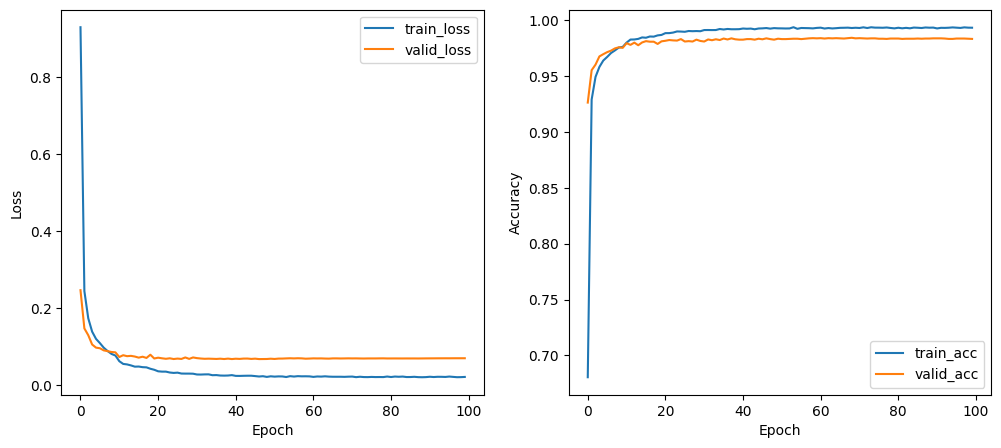

In [67]:
# Plot training and validation loss and accuracy curves
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(train_loss, label="train_loss")
plt.plot(valid_loss, label="valid_loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_acc, label="train_acc")
plt.plot(valid_acc, label="valid_acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()